# 12 · Pruning reference and granularity audit

**Single responsibility:** freeze the Fast-80 baseline, enumerate every legal pruning unit,
map channel dependencies, and demonstrate which pruning granularities can actually reduce
dense ESP32 work.

This is the first notebook in the restarted pruning phase. It deliberately does **not** train,
prune, quantize, or select a candidate. Instead, it creates the structural contract that every
later experiment must obey. Notebook 13 will introduce the first actual technique:
unstructured magnitude pruning.

## Evidence flow

```text
Frozen Fast-80 files
        ↓ hashes + assertions
Keras/TFLite/device baseline inventory
        ↓
Per-layer pruning-unit inventory
        ↓
Depthwise-separable dependency graph
        ↓
Granularity masks + physical-work counterexample
        ↓
ESP32 support matrix and experiment gate
```

Each code cell performs one logical operation. Generated tables and figures are written to
`artifacts/pruning/reference_audit/` so later notebooks can consume exactly the same baseline.

## 0 · Locate the repository before importing project code

The notebook may be launched from the repository root, `notebooks/`, or
`optimization/pruning/`. This cell finds `configs/base.yaml`, configures a writable Matplotlib
cache, and places `src/` on the import path.

In [1]:
import os
import sys
from pathlib import Path

current = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (current, *current.parents)
    if (candidate / "configs" / "base.yaml").exists()
)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))
sys.path.insert(0, str(ROOT / "src"))
print(f"Repository: {ROOT}")

Repository: /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32


## 1 · Import deterministic analysis dependencies

No training data are loaded in this notebook. TensorFlow is used only to restore the frozen
Keras graph; the device CSV is the source of physical batch-one latency.

In [2]:
import hashlib
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown, display

from vww_esp32.device_profiling import tflite_operator_inventory
from vww_esp32.profiling import human_bytes, profile_model

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

print({
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
})

{'python': '3.10.13', 'tensorflow': '2.20.0', 'numpy': '2.1.3', 'pandas': '2.3.3'}


## 2 · Declare inputs and clean output namespaces

The float model is used for structural analysis. The deployed full-INT8 TFLite file and the
recorded ESP32 profile anchor storage, tensor-arena, and physical latency. Outputs are kept
separate from the frozen Fast-80 artifacts.

In [3]:
CONFIG_PATH = ROOT / "configs" / "fast_80.yaml"
FLOAT_MODEL_PATH = ROOT / "artifacts" / "fast_80" / "models" / "final.keras"
INT8_MODEL_PATH = ROOT / "artifacts" / "fast_80" / "models" / "vww_mobilenetv1_80_int8.tflite"
DATA_MANIFEST_PATH = ROOT / "data" / "processed" / "manifest.csv"
DEVICE_SUMMARY_PATH = ROOT / "artifacts" / "device_profiles" / "fast_80" / "device_profile_summary.json"
DEVICE_OPERATORS_PATH = ROOT / "artifacts" / "device_profiles" / "fast_80" / "operator_profile.csv"

OUTPUT_DIR = ROOT / "artifacts" / "pruning" / "reference_audit"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

required_inputs = [
    CONFIG_PATH,
    FLOAT_MODEL_PATH,
    INT8_MODEL_PATH,
    DATA_MANIFEST_PATH,
    DEVICE_SUMMARY_PATH,
    DEVICE_OPERATORS_PATH,
]
missing = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing, f"Missing required inputs: {missing}"
print(f"Output directory: {OUTPUT_DIR.relative_to(ROOT)}")

Output directory: artifacts/pruning/reference_audit


## 3 · Freeze file identities

A result is comparable only if it starts from the same checkpoint, TFLite file, dataset split,
and device profile. SHA-256 hashes make accidental baseline changes visible.

In [4]:
def sha256_file(path: Path, chunk_bytes: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()


input_hashes = {
    str(path.relative_to(ROOT)): sha256_file(path)
    for path in required_inputs
}
hash_table = pd.DataFrame(
    [{"artifact": name, "sha256": digest} for name, digest in input_hashes.items()]
)
display(hash_table.style.hide(axis="index"))

artifact,sha256
configs/fast_80.yaml,96481848d8adcc955801e37537dda34cfdbb3c6c3a3f58004547e8d0da21f96c
artifacts/fast_80/models/final.keras,1fbfb79a810f4a4efa17d3a2760fd059e0338e4d5d5121ba7998259db81a4acf
artifacts/fast_80/models/vww_mobilenetv1_80_int8.tflite,70eb89724ae7f5f84097922e481ba8c61946ef7219fdbeddabc81a612ae7691d
data/processed/manifest.csv,6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242f15517680652e38704
artifacts/device_profiles/fast_80/device_profile_summary.json,9dcc37c9674c0050a608c92b6be290eb1afb0ae0de6385edc321109ee1037d34
artifacts/device_profiles/fast_80/operator_profile.csv,0e156d3a0c1933d2d115418b5911d0e5d6a8f1edaf0f080298de951d8cee4b86


## 4 · Load the frozen model and measured device evidence

`compile=False` avoids restoring optimizer state. The physical timing values are read from the
previous 20-invocation batch-one board run; this notebook never substitutes desktop timing for
ESP32 timing.

In [5]:
model = tf.keras.models.load_model(FLOAT_MODEL_PATH, compile=False)
with DEVICE_SUMMARY_PATH.open(encoding="utf-8") as handle:
    device = json.load(handle)
device_operators = pd.read_csv(DEVICE_OPERATORS_PATH)
tflite_operators = tflite_operator_inventory(INT8_MODEL_PATH)

assert tuple(model.input_shape[1:]) == (80, 80, 3)
assert int(device["batch"]) == 1
assert int(device["model_bytes"]) == INT8_MODEL_PATH.stat().st_size
assert len(device_operators) == int(device["operators"])
assert len(tflite_operators) == int(device["operators"])

print(
    f"Loaded {model.name}: {len(model.layers)} Keras layers, "
    f"{len(tflite_operators)} fused TFLite operators"
)

Loaded tiny_mobilenet_v1_0.25: 70 Keras layers, 26 fused TFLite operators


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 5 · Recompute the layer and activation inventories

This uses the project profiler instead of trusting a stale CSV. MACs are dense batch-one MACs.
Activation liveness is a graph estimate; actual TFLM arena use comes from the device summary.

In [6]:
layer_profile, activation_liveness, model_summary = profile_model(
    model,
    batch_size=1,
    training_batch_size=64,
)
layer_profile.to_csv(OUTPUT_DIR / "layer_inventory.csv", index=False)
activation_liveness.to_csv(OUTPUT_DIR / "activation_liveness.csv", index=False)

assert int(model_summary["parameters"]) == 111_793
assert int(model_summary["estimated_macs_batch1"]) == 3_993_536
print(
    f"Parameters: {model_summary['parameters']:,} | "
    f"Dense MACs: {model_summary['estimated_macs_batch1']:,} | "
    f"Float graph live peak: {human_bytes(model_summary['peak_live_activation_float32_bytes_batch1'])}"
)

Parameters: 111,793 | Dense MACs: 3,993,536 | Float graph live peak: 200.00 KiB


## 6 · Write the baseline contract

Later notebooks must copy this contract and report deltas against it. The distinction between
graph activation liveness, FlatBuffer size, and measured TFLM arena use is preserved explicitly.

In [7]:
baseline_contract = {
    "experiment": "pruning_reference_audit",
    "seed": SEED,
    "input_shape": [1, 80, 80, 3],
    "batch_size": 1,
    "float_parameters": int(model_summary["parameters"]),
    "dense_macs_batch1": int(model_summary["estimated_macs_batch1"]),
    "int8_tflite_bytes": int(INT8_MODEL_PATH.stat().st_size),
    "tflite_live_activation_peak_bytes": int(device["tflite_live_activation_peak_bytes"]),
    "tflm_arena_used_bytes": int(device["arena_used_bytes"]),
    "tflm_arena_reserved_bytes": int(device["tensor_arena_reserved_bytes"]),
    "device_invoke_mean_us": float(device["mean_us"]),
    "device_invoke_min_us": int(device["min_us"]),
    "device_invoke_max_us": int(device["max_us"]),
    "device_profile_samples": int(device["samples"]),
    "fused_tflite_operators": int(device["operators"]),
    "hashes": input_hashes,
    "measurement_scope": {
        "macs": "static dense estimate",
        "live_activations": "FlatBuffer tensor-liveness estimate",
        "arena": "MicroAllocator value measured on ESP32-CAM",
        "latency": "batch-one Invoke measured on ESP32-CAM",
    },
}
(OUTPUT_DIR / "baseline_contract.json").write_text(
    json.dumps(baseline_contract, indent=2) + "\n",
    encoding="utf-8",
)

baseline_table = pd.DataFrame(
    {
        "Metric": [
            "Input", "Parameters", "Dense MACs / image", "INT8 TFLite",
            "TFLite live activation peak", "Measured TFLM arena used",
            "Measured Invoke mean", "Fused operators",
        ],
        "Frozen Fast-80 reference": [
            "1 × 80 × 80 × 3", f"{model_summary['parameters']:,}",
            f"{model_summary['estimated_macs_batch1']:,}", human_bytes(INT8_MODEL_PATH.stat().st_size),
            human_bytes(device["tflite_live_activation_peak_bytes"]), human_bytes(device["arena_used_bytes"]),
            f"{device['mean_us'] / 1000:.2f} ms", f"{device['operators']}",
        ],
    }
)
display(baseline_table.style.hide(axis="index"))

Metric,Frozen Fast-80 reference
Input,1 × 80 × 80 × 3
Parameters,"111,793"
Dense MACs / image,"3,993,536"
INT8 TFLite,164.04 KiB
TFLite live activation peak,37.50 KiB
Measured TFLM arena used,67.45 KiB
Measured Invoke mean,455.55 ms
Fused operators,26


## 7 · Locate where compute, parameters, and device time are concentrated

A pruning ratio is not useful by itself. This figure shows which dense stages own the MACs and
parameters, and which fused operators consumed time on the actual ESP32-CAM. It guides later
sensitivity tests without selecting channels prematurely.

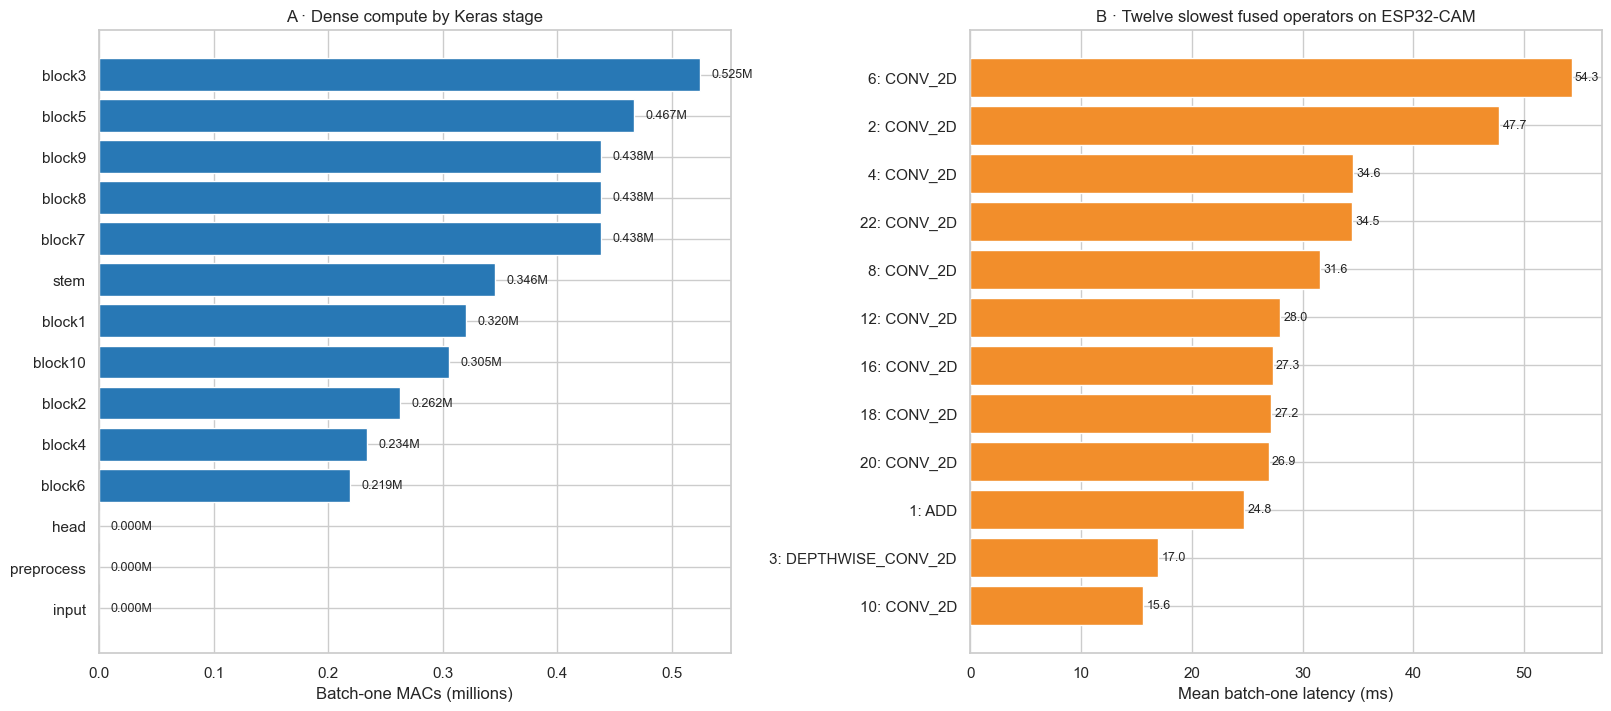

artifacts/pruning/reference_audit/figures/baseline_resource_concentration.png


In [8]:
stage_profile = (
    layer_profile.groupby("stage", as_index=False)
    .agg(parameters=("parameters", "sum"), macs=("estimated_macs_batch1", "sum"))
)
stage_profile["parameter_share"] = stage_profile["parameters"] / stage_profile["parameters"].sum()
stage_profile["mac_share"] = stage_profile["macs"] / stage_profile["macs"].sum()

device_operators["mean_ms"] = device_operators["mean_us"] / 1000.0
device_operators["label"] = device_operators.apply(
    lambda row: f"{int(row['index'])}: {row['operator']}", axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
ordered = stage_profile.sort_values("macs")
axes[0].barh(ordered["stage"], ordered["macs"] / 1e6, color="#2878B5", label="MACs")
axes[0].set(title="A · Dense compute by Keras stage", xlabel="Batch-one MACs (millions)", ylabel="")
for y, value in enumerate(ordered["macs"] / 1e6):
    axes[0].text(value + 0.01, y, f"{value:.3f}M", va="center", fontsize=9)

top_device = device_operators.nlargest(12, "mean_ms").sort_values("mean_ms")
axes[1].barh(top_device["label"], top_device["mean_ms"], color="#F28E2B")
axes[1].set(title="B · Twelve slowest fused operators on ESP32-CAM", xlabel="Mean batch-one latency (ms)", ylabel="")
for y, value in enumerate(top_device["mean_ms"]):
    axes[1].text(value + 0.3, y, f"{value:.1f}", va="center", fontsize=9)

figure_path = FIGURE_DIR / "baseline_resource_concentration.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 8 · Enumerate pruning units for every convolution

Granularity changes the number of selectable groups. For a standard convolution kernel
`[Kh, Kw, Cin, Cout]`, scalar weights, channel-pair kernels, and output channels are different
units. For a depthwise kernel `[Kh, Kw, Cin, multiplier]`, each output channel is tied to one
input channel, so independent channel deletion is legal only when the upstream dependency is
changed too.

In [9]:
pruning_rows = []
for layer in model.layers:
    if not isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
        continue
    kernel = np.asarray(layer.get_weights()[0])
    kh, kw = kernel.shape[:2]
    if isinstance(layer, tf.keras.layers.DepthwiseConv2D):
        cin, multiplier = kernel.shape[2], kernel.shape[3]
        cout = cin * multiplier
        connection_groups = cout
        independent_output_pruning = False
        role = "depthwise"
    else:
        cin, cout = kernel.shape[2], kernel.shape[3]
        multiplier = np.nan
        connection_groups = cin * cout
        independent_output_pruning = True
        role = "stem" if layer.name == "stem_conv" else "pointwise"
    pruning_rows.append(
        {
            "layer": layer.name,
            "role": role,
            "kernel_shape": "×".join(map(str, kernel.shape)),
            "kh": kh,
            "kw": kw,
            "input_channels": cin,
            "output_channels": cout,
            "scalar_units": kernel.size,
            "kernel_connection_units": connection_groups,
            "output_channel_units": cout,
            "dense_kernel_bytes_float32": kernel.nbytes,
            "independent_output_pruning": independent_output_pruning,
        }
    )

pruning_units = pd.DataFrame(pruning_rows)
pruning_units.to_csv(OUTPUT_DIR / "pruning_unit_inventory.csv", index=False)
assert set(pruning_units["layer"]) == {
    layer.name
    for layer in model.layers
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D))
}
display(pruning_units.style.hide(axis="index").format({"dense_kernel_bytes_float32": "{:,}"}))

layer,role,kernel_shape,kh,kw,input_channels,output_channels,scalar_units,kernel_connection_units,output_channel_units,dense_kernel_bytes_float32,independent_output_pruning
stem_conv,stem,3×3×3×8,3,3,3,8,216,24,8,864,True
block1_dw,depthwise,3×3×8×1,3,3,8,8,72,8,8,288,False
block1_pw,pointwise,1×1×8×16,1,1,8,16,128,128,16,512,True
block2_dw,depthwise,3×3×16×1,3,3,16,16,144,16,16,576,False
block2_pw,pointwise,1×1×16×32,1,1,16,32,512,512,32,"2,048",True
block3_dw,depthwise,3×3×32×1,3,3,32,32,288,32,32,"1,152",False
block3_pw,pointwise,1×1×32×32,1,1,32,32,1024,1024,32,"4,096",True
block4_dw,depthwise,3×3×32×1,3,3,32,32,288,32,32,"1,152",False
block4_pw,pointwise,1×1×32×64,1,1,32,64,2048,2048,64,"8,192",True
block5_dw,depthwise,3×3×64×1,3,3,64,64,576,64,64,"2,304",False


## 9 · Build channel-dependency groups

Physical channel pruning must change every tensor that carries the same channel identity.
For a pointwise output, that includes its BatchNorm entry, the next depthwise kernel and
BatchNorm, and the next pointwise input slice. The classifier head is the terminal special case.

In [10]:
producer_names = ["stem_conv"] + [f"block{i}_pw" for i in range(1, 11)]
dependency_rows = []

for producer_index, producer_name in enumerate(producer_names):
    producer = model.get_layer(producer_name)
    output_channels = int(producer.output.shape[-1])
    if producer_name == "stem_conv":
        dependent_objects = ["stem_bn", "block1_dw", "block1_dw_bn", "block1_pw:input"]
    elif producer_name == "block10_pw":
        dependent_objects = ["block10_pw_bn", "global_average", "person_probability:input"]
    else:
        block = int(producer_name.split("block")[1].split("_")[0])
        next_block = block + 1
        dependent_objects = [
            f"block{block}_pw_bn",
            f"block{next_block}_dw",
            f"block{next_block}_dw_bn",
            f"block{next_block}_pw:input",
        ]
    for order, dependent in enumerate(dependent_objects):
        dependency_rows.append(
            {
                "group_id": producer_index,
                "producer": producer_name,
                "channels": output_channels,
                "dependency_order": order,
                "dependent_object": dependent,
            }
        )

dependency_edges = pd.DataFrame(dependency_rows)
dependency_edges.to_csv(OUTPUT_DIR / "channel_dependency_edges.csv", index=False)
assert dependency_edges.groupby("producer")["channels"].nunique().eq(1).all()
display(dependency_edges.head(12).style.hide(axis="index"))

group_id,producer,channels,dependency_order,dependent_object
0,stem_conv,8,0,stem_bn
0,stem_conv,8,1,block1_dw
0,stem_conv,8,2,block1_dw_bn
0,stem_conv,8,3,block1_pw:input
1,block1_pw,16,0,block1_pw_bn
1,block1_pw,16,1,block2_dw
1,block1_pw,16,2,block2_dw_bn
1,block1_pw,16,3,block2_pw:input
2,block2_pw,32,0,block2_pw_bn
2,block2_pw,32,1,block3_dw


## 10 · Validate every dependency against the graph

Names ending in `:input` denote a tensor axis, not a standalone Keras layer. The checks below
verify channel counts across all real layers so a later rebuild cannot silently create a
mismatched depthwise-separable chain.

In [11]:
dependency_checks = []
for producer_name in producer_names:
    producer = model.get_layer(producer_name)
    channels = int(producer.output.shape[-1])
    if producer_name == "block10_pw":
        dependent_layer = model.get_layer("person_probability")
        observed = int(dependent_layer.input.shape[-1])
        target = "person_probability input"
    else:
        next_dw_name = "block1_dw" if producer_name == "stem_conv" else f"block{int(producer_name[5:producer_name.index('_')]) + 1}_dw"
        dependent_layer = model.get_layer(next_dw_name)
        observed = int(dependent_layer.input.shape[-1])
        target = next_dw_name
    dependency_checks.append(
        {"producer": producer_name, "producer_channels": channels, "dependent": target, "dependent_channels": observed, "valid": channels == observed}
    )

dependency_validation = pd.DataFrame(dependency_checks)
assert dependency_validation["valid"].all()
dependency_validation.to_csv(OUTPUT_DIR / "channel_dependency_validation.csv", index=False)
display(dependency_validation.style.hide(axis="index"))

producer,producer_channels,dependent,dependent_channels,valid
stem_conv,8,block1_dw,8,True
block1_pw,16,block2_dw,16,True
block2_pw,32,block3_dw,32,True
block3_pw,32,block4_dw,32,True
block4_pw,64,block5_dw,64,True
block5_pw,64,block6_dw,64,True
block6_pw,128,block7_dw,128,True
block7_pw,128,block8_dw,128,True
block8_pw,128,block9_dw,128,True
block9_pw,128,block10_dw,128,True


## 11 · Visualize the physical channel-removal path

The full stage chain is shown above; this representative group expands one channel identity.
Removing channel `i` from `block7_pw` requires the same index to disappear from all four
dependent objects. Merely zeroing the pointwise filter leaves the graph shape unchanged.

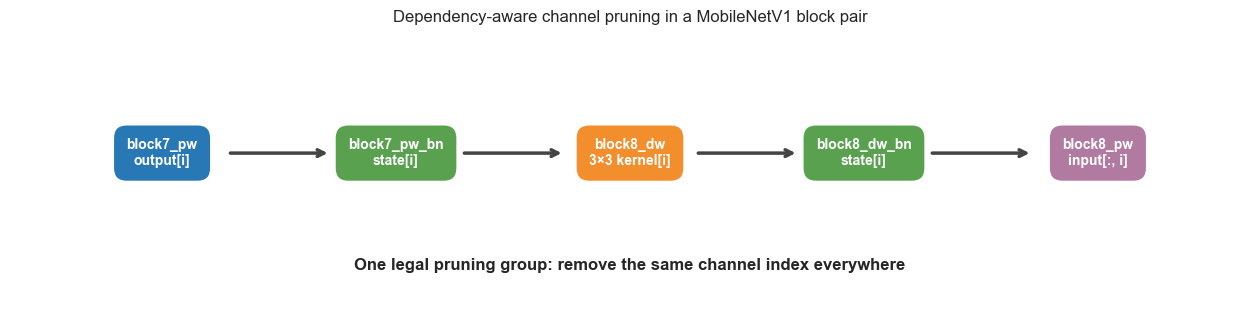

artifacts/pruning/reference_audit/figures/channel_dependency_path.png


In [12]:
chain_nodes = [
    ("block7_pw\noutput[i]", "producer"),
    ("block7_pw_bn\nstate[i]", "normalization"),
    ("block8_dw\n3×3 kernel[i]", "depthwise"),
    ("block8_dw_bn\nstate[i]", "normalization"),
    ("block8_pw\ninput[:, i]", "consumer"),
]
colors = {
    "producer": "#2878B5",
    "normalization": "#59A14F",
    "depthwise": "#F28E2B",
    "consumer": "#B07AA1",
}
fig, ax = plt.subplots(figsize=(16, 3.8))
x_positions = np.arange(len(chain_nodes))
for index, ((label, kind), x) in enumerate(zip(chain_nodes, x_positions)):
    ax.text(
        x,
        0,
        label,
        ha="center",
        va="center",
        color="white",
        weight="bold",
        fontsize=10,
        zorder=4,
        bbox={"boxstyle": "round,pad=0.9", "facecolor": colors[kind], "edgecolor": "none"},
    )
    if index < len(chain_nodes) - 1:
        ax.annotate("", xy=(x + 0.72, 0), xytext=(x + 0.28, 0), arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "#444444"})
ax.text(2, -0.62, "One legal pruning group: remove the same channel index everywhere", ha="center", fontsize=12, weight="bold")
ax.set(xlim=(-0.65, 4.65), ylim=(-0.9, 0.65), title="Dependency-aware channel pruning in a MobileNetV1 block pair")
ax.axis("off")
figure_path = FIGURE_DIR / "channel_dependency_path.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 12 · Construct deterministic masks at multiple granularities

The following toy tensor uses one fixed importance map so only granularity changes. Red cells
are preserved and light cells are pruned. These masks explain structure—not accuracy—and are
never assigned to the frozen model.

In [13]:
rng = np.random.default_rng(SEED)
importance = rng.uniform(size=(12, 12))

fine_mask = importance >= np.quantile(importance, 0.50)

pattern_mask = np.zeros_like(fine_mask)
cross_pattern = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=bool)
for row in range(0, 12, 3):
    for col in range(0, 12, 3):
        pattern_mask[row:row + 3, col:col + 3] = cross_pattern

mn_mask = np.zeros_like(fine_mask)
for row in range(12):
    for col in range(0, 12, 4):
        group = importance[row, col:col + 4]
        keep = np.argsort(group)[-2:]
        mn_mask[row, col + keep] = True

kernel_scores = importance.reshape(6, 2, 6, 2).mean(axis=(1, 3))
kernel_mask = (kernel_scores >= np.median(kernel_scores)).repeat(2, axis=0).repeat(2, axis=1)

channel_scores = importance.mean(axis=1)
channel_mask = np.repeat((channel_scores >= np.median(channel_scores))[:, None], 12, axis=1)

block_mask = np.zeros_like(fine_mask)
block_mask[:6, :] = True

granularity_masks = {
    "Fine-grained\nscalar": fine_mask,
    "Pattern-based\n3×3 library": pattern_mask,
    "Vector / M:N\n2:4": mn_mask,
    "Kernel connection\ngrouped 2×2 view": kernel_mask,
    "Channel-level\nwhole rows": channel_mask,
    "Block-level\nwhole structure": block_mask,
}
{name: float(mask.mean()) for name, mask in granularity_masks.items()}

{'Fine-grained\nscalar': 0.5,
 'Pattern-based\n3×3 library': 0.5555555555555556,
 'Vector / M:N\n2:4': 0.5,
 'Kernel connection\ngrouped 2×2 view': 0.5,
 'Channel-level\nwhole rows': 0.5,
 'Block-level\nwhole structure': 0.5}

## 13 · Compare mask regularity visually

Moving right increases structural regularity. Regularity alone does not guarantee speed: the
runtime must understand the pattern, or the graph must be rebuilt into smaller dense tensors.

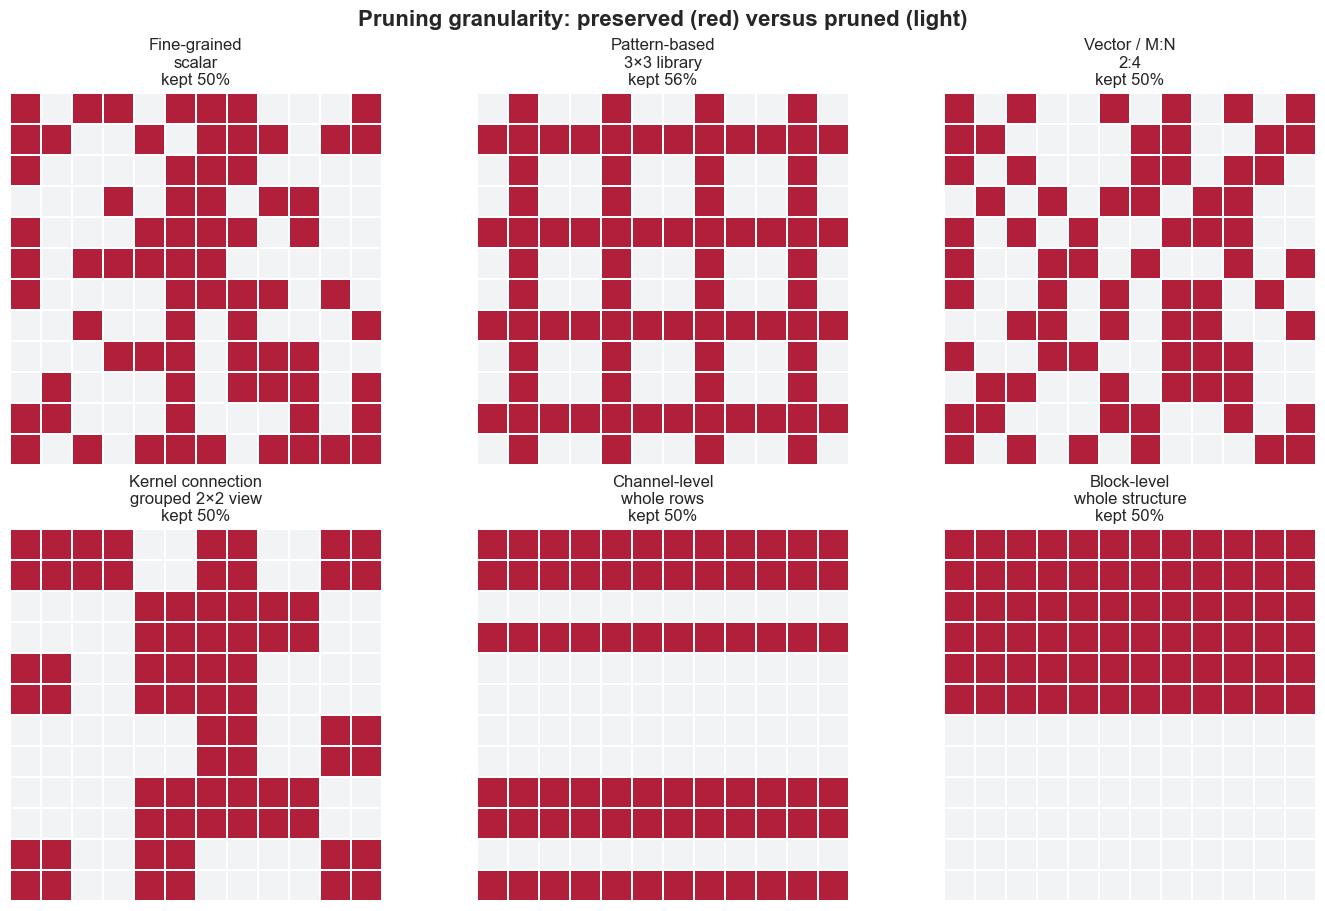

artifacts/pruning/reference_audit/figures/pruning_granularity_masks.png


In [14]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
mask_cmap = ListedColormap(["#F1F3F5", "#B11F3A"])
for ax, (title, mask) in zip(axes.flat, granularity_masks.items()):
    sns.heatmap(mask.astype(int), cmap=mask_cmap, cbar=False, square=True, linewidths=0.35, linecolor="white", ax=ax)
    ax.set_title(f"{title}\nkept {mask.mean():.0%}")
    ax.set(xticks=[], yticks=[], xlabel="", ylabel="")
fig.suptitle("Pruning granularity: preserved (red) versus pruned (light)", fontsize=16, weight="bold")
figure_path = FIGURE_DIR / "pruning_granularity_masks.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 14 · Quantify the “zeros are not speed” counterexample

This controlled example applies a nominal 50% budget to the real `block7_pw` dimensions.
Unstructured, 2:4, and kernel-connection masks halve mathematical nonzeros but keep the dense
tensor shape, dense serialization, executed dense MACs, and output activation unchanged under
stock TFLite Micro/ESP-NN. Physical channel removal rebuilds a narrower dense tensor; whole
block removal deletes the operation. Accuracy is intentionally unknown until those techniques
are trained and evaluated in later notebooks.

In [15]:
representative = layer_profile.set_index("layer_name").loc["block7_pw"]
baseline_weights = int(representative["parameters"])
baseline_macs = int(representative["estimated_macs_batch1"])
baseline_activation = int(representative["output_int8_bytes_batch1_hypothetical"])

technique_rows = [
    ("Dense baseline", 1.0, 1.0, 1.0, 1.0, "dense"),
    ("Unstructured 50% mask", 0.5, 1.0, 1.0, 1.0, "masked dense"),
    ("2:4 mask", 0.5, 1.0, 1.0, 1.0, "masked dense"),
    ("Kernel connections 50%", 0.5, 1.0, 1.0, 1.0, "masked dense"),
    ("Physical output channels 50%", 0.5, 0.5, 0.5, 0.5, "rebuilt dense"),
    ("Whole block removal", 0.0, 0.0, 0.0, 0.0, "deleted dense op"),
]
effect_rows = []
for name, nonzero_ratio, stored_ratio, mac_ratio, activation_ratio, representation in technique_rows:
    effect_rows.append(
        {
            "technique": name,
            "representation": representation,
            "mathematical_nonzero_weights": round(baseline_weights * nonzero_ratio),
            "physical_dense_weights": round(baseline_weights * stored_ratio),
            "dense_executed_macs": round(baseline_macs * mac_ratio),
            "output_activation_bytes": round(baseline_activation * activation_ratio),
            "nonzero_ratio": nonzero_ratio,
            "physical_weight_ratio": stored_ratio,
            "dense_mac_ratio": mac_ratio,
            "activation_ratio": activation_ratio,
        }
    )
granularity_effect = pd.DataFrame(effect_rows)
granularity_effect.to_csv(OUTPUT_DIR / "granularity_physical_effect.csv", index=False)
display(
    granularity_effect[
        ["technique", "representation", "mathematical_nonzero_weights", "physical_dense_weights", "dense_executed_macs", "output_activation_bytes"]
    ].style.hide(axis="index").format({
        "mathematical_nonzero_weights": "{:,}",
        "physical_dense_weights": "{:,}",
        "dense_executed_macs": "{:,}",
        "output_activation_bytes": "{:,}",
    })
)

technique,representation,mathematical_nonzero_weights,physical_dense_weights,dense_executed_macs,output_activation_bytes
Dense baseline,dense,"16,384","16,384","409,600","3,200"
Unstructured 50% mask,masked dense,"8,192","16,384","409,600","3,200"
2:4 mask,masked dense,"8,192","16,384","409,600","3,200"
Kernel connections 50%,masked dense,"8,192","16,384","409,600","3,200"
Physical output channels 50%,rebuilt dense,"8,192","8,192","204,800","1,600"
Whole block removal,deleted dense op,0,0,0,0


## 15 · Visualize logical sparsity versus physical savings

The gap between the blue nonzero bar and the orange/green physical bars is the central systems
lesson. Stock dense kernels do not skip masked zeros. Only a smaller dense graph—or a custom
sparse representation plus matching kernel—changes executed work.

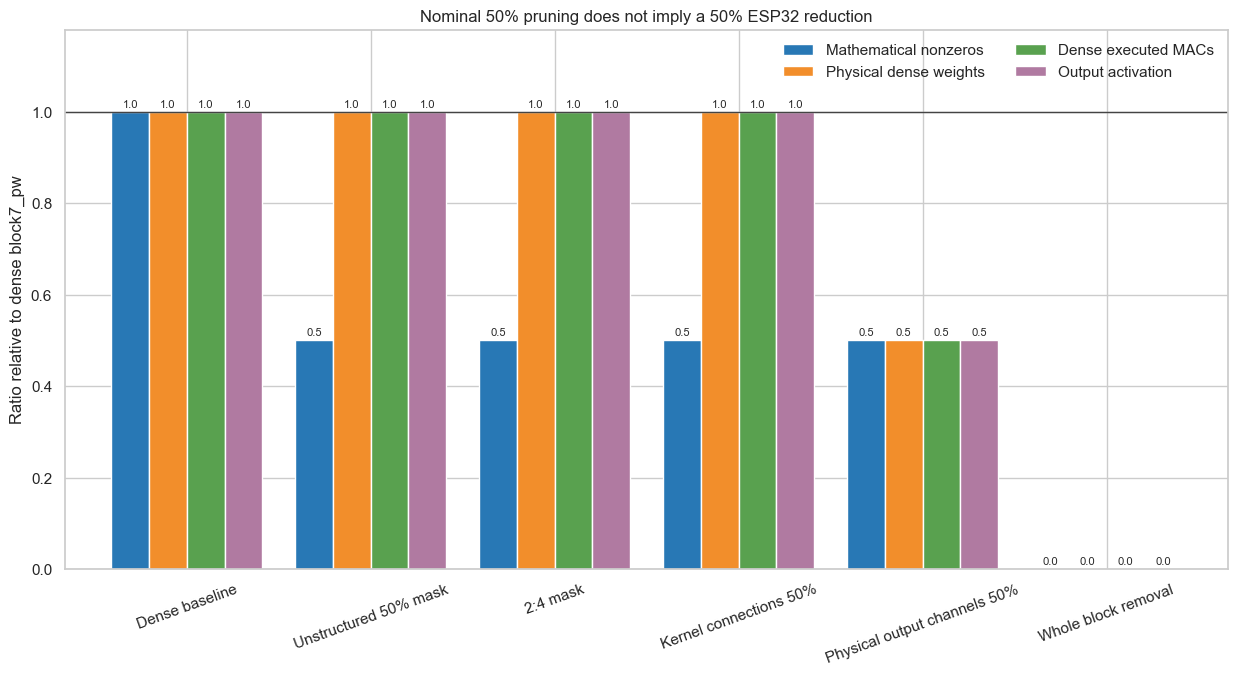

artifacts/pruning/reference_audit/figures/logical_vs_physical_pruning_effect.png


In [16]:
plot_effect = granularity_effect.set_index("technique")[[
    "nonzero_ratio", "physical_weight_ratio", "dense_mac_ratio", "activation_ratio"
]].rename(columns={
    "nonzero_ratio": "Mathematical nonzeros",
    "physical_weight_ratio": "Physical dense weights",
    "dense_mac_ratio": "Dense executed MACs",
    "activation_ratio": "Output activation",
})
ax = plot_effect.plot(kind="bar", figsize=(15, 7), width=0.82, color=["#2878B5", "#F28E2B", "#59A14F", "#B07AA1"])
ax.axhline(1.0, color="#444444", linewidth=1)
ax.set(
    title="Nominal 50% pruning does not imply a 50% ESP32 reduction",
    xlabel="",
    ylabel="Ratio relative to dense block7_pw",
    ylim=(0, 1.18),
)
ax.tick_params(axis="x", rotation=20)
ax.legend(ncol=2, frameon=False, loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)
figure_path = FIGURE_DIR / "logical_vs_physical_pruning_effect.png"
ax.figure.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 16 · Encode the ESP32 runtime support matrix

“Supported” here means the current dense TFLite Micro + ESP-NN deployment can realize less
work after conversion. Fine-grained, pattern, vector/M:N, and kernel-connection pruning still
require a sparse encoding and matching custom kernel. Channel and legal block pruning can reuse
dense kernels after physically rebuilding the graph.

In [17]:
support_matrix = pd.DataFrame(
    [
        ("Fine-grained", False, False, False, True, "control"),
        ("Pattern", False, False, False, True, "research"),
        ("Vector / M:N", False, False, False, True, "research"),
        ("Kernel connection", False, False, False, True, "analysis"),
        ("Channel / filter", True, True, True, False, "highest"),
        ("Layer / block", True, True, False, False, "high"),
    ],
    columns=[
        "granularity",
        "smaller_dense_graph",
        "stock_esp_nn_less_work",
        "activation_shape_can_shrink",
        "custom_sparse_kernel_required",
        "priority",
    ],
)
support_matrix.to_csv(OUTPUT_DIR / "granularity_support_matrix.csv", index=False)
display(support_matrix.style.hide(axis="index"))

granularity,smaller_dense_graph,stock_esp_nn_less_work,activation_shape_can_shrink,custom_sparse_kernel_required,priority
Fine-grained,False,False,False,True,control
Pattern,False,False,False,True,research
Vector / M:N,False,False,False,True,research
Kernel connection,False,False,False,True,analysis
Channel / filter,True,True,True,False,highest
Layer / block,True,True,False,False,high


## 17 · Visualize the deployment decision matrix

Green cells identify an immediately usable property; red cells identify a missing property or
custom-kernel requirement. This matrix determines the order of experiments, not their expected
accuracy.

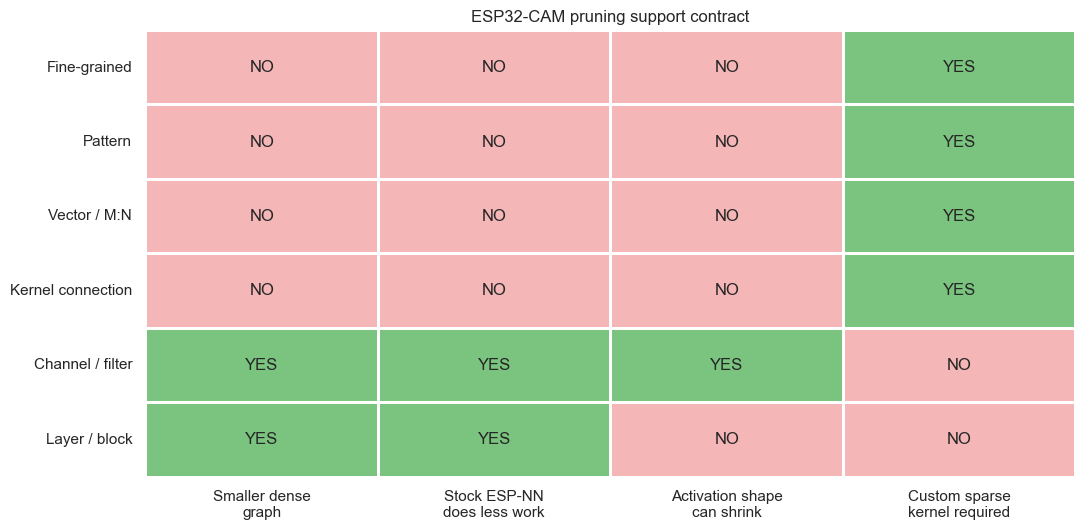

artifacts/pruning/reference_audit/figures/esp32_pruning_support_matrix.png


In [18]:
support_columns = [
    "smaller_dense_graph",
    "stock_esp_nn_less_work",
    "activation_shape_can_shrink",
    "custom_sparse_kernel_required",
]
support_plot = support_matrix.set_index("granularity")[support_columns].astype(int)
annotations = support_plot.replace({1: "YES", 0: "NO"})

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.heatmap(
    support_plot,
    annot=annotations,
    fmt="",
    cmap=ListedColormap(["#F4B6B6", "#7BC47F"]),
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=ax,
)
ax.set_title("ESP32-CAM pruning support contract")
ax.set(xlabel="", ylabel="")
ax.set_xticklabels([
    "Smaller dense\ngraph",
    "Stock ESP-NN\ndoes less work",
    "Activation shape\ncan shrink",
    "Custom sparse\nkernel required",
], rotation=0)
figure_path = FIGURE_DIR / "esp32_pruning_support_matrix.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 18 · Derive the first experiment gate

Notebook 13 may report accuracy and compression from unstructured magnitude pruning, but it
must retain the baseline dense MACs, activation shapes, and expected stock ESP-NN work unless a
custom sparse kernel is added. Notebook 14 is the first experiment allowed to claim dense
compute reduction because it will physically rebuild channels.

In [19]:
experiment_gate = pd.DataFrame(
    [
        (13, "Unstructured global magnitude", "masked dense", False, "Scientific control; no stock ESP-NN speed claim"),
        (14, "L1/L2 structured channel magnitude", "rebuilt dense", True, "First candidate for physical size/MAC/arena/latency reduction"),
    ],
    columns=["notebook", "new decision", "required representation", "device_speed_claim_allowed", "purpose"],
)
experiment_gate.to_csv(OUTPUT_DIR / "next_experiment_gate.csv", index=False)
display(experiment_gate.style.hide(axis="index"))

notebook,new decision,required representation,device_speed_claim_allowed,purpose
13,Unstructured global magnitude,masked dense,False,Scientific control; no stock ESP-NN speed claim
14,L1/L2 structured channel magnitude,rebuilt dense,True,First candidate for physical size/MAC/arena/latency reduction


## 19 · Write a machine-readable audit manifest

The manifest records every table and figure produced here. Later reports can verify hashes and
reuse these paths without scraping notebook output.

In [20]:
generated_files = sorted(path for path in OUTPUT_DIR.rglob("*") if path.is_file())
audit_manifest = {
    "notebook": "optimization/pruning/12_pruning_reference_and_granularity_audit.ipynb",
    "status": "complete",
    "changes_model_weights": False,
    "changes_model_topology": False,
    "claims_device_speedup": False,
    "baseline_contract": baseline_contract,
    "generated_artifacts": [
        {
            "path": str(path.relative_to(ROOT)),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in generated_files
        if path.name != "audit_manifest.json"
    ],
}
manifest_path = OUTPUT_DIR / "audit_manifest.json"
manifest_path.write_text(json.dumps(audit_manifest, indent=2) + "\n", encoding="utf-8")
display(pd.DataFrame(audit_manifest["generated_artifacts"]).style.hide(axis="index"))

path,bytes,sha256
artifacts/pruning/reference_audit/activation_liveness.csv,3339,b593f7fdbd4f9e96967744c3c9694b4a7be9eb3154e7342378a865ce9e5eb88a
artifacts/pruning/reference_audit/baseline_contract.json,1485,01afdcf1544e8d1712afe300bddc044b30b314d625ac3558922a18fa885be9e5
artifacts/pruning/reference_audit/channel_dependency_edges.csv,1385,ad443c35cca99bc12b9a7ec385b6eff6d8270e090a30547e5a35613955a78858
artifacts/pruning/reference_audit/channel_dependency_validation.csv,428,63e16a13bc682911f2ebe70d1f555c079de0c744c416ab32872fe3ba05cd27eb
artifacts/pruning/reference_audit/figures/baseline_resource_concentration.png,171232,37c3ae73cf7e5a7b9b737fa55481cabe18f4ffb6a63462fa8267a61c457a083d
artifacts/pruning/reference_audit/figures/channel_dependency_path.png,60759,2da2c3295080a4f19c6671d75fbd377b930b565eb3a7ff3a7b6f47d4234553d3
artifacts/pruning/reference_audit/figures/esp32_pruning_support_matrix.png,75867,a518d2bd71f863084d4b17e3daec063c9ec43cfaf822aa3ce81cbe85fc4d3656
artifacts/pruning/reference_audit/figures/logical_vs_physical_pruning_effect.png,120125,614a6d508f6feccbd6ee7d56f8a7d729595c9eb5dbfb815397627d9d88727ae3
artifacts/pruning/reference_audit/figures/pruning_granularity_masks.png,77400,eb32ddba4d7a85b9d2bcccc948591da1c0279b6235ebea0769e1d4350700b52c
artifacts/pruning/reference_audit/granularity_physical_effect.csv,603,22f4ca1b08fa013924ec0bb06d0abb35f85c0eb8e587e2116509a67c096346d0


## 20 · Findings and hand-off

This cell turns the computed evidence into the exact conclusions that control Notebook 13.
No conclusion depends on a manually typed performance estimate.

In [21]:
slowest = device_operators.nlargest(1, "mean_ms").iloc[0]
conv_time_share = (
    device_operators.loc[
        device_operators["operator"].isin(["CONV_2D", "DEPTHWISE_CONV_2D"]),
        "mean_us",
    ].sum()
    / device_operators["mean_us"].sum()
)
channel_groups = dependency_edges["producer"].nunique()

conclusion = (
    "**Audit complete.**\n\n"
    f"- The frozen reference remains **{model_summary['parameters']:,} parameters**, "
    f"**{model_summary['estimated_macs_batch1']:,} dense MACs**, and "
    f"**{INT8_MODEL_PATH.stat().st_size:,} TFLite bytes**.\n"
    f"- The physical batch-one ESP32-CAM Invoke mean is **{device['mean_us'] / 1000:.2f} ms**; "
    f"convolution and depthwise convolution account for **{conv_time_share:.1%}** of profiled operator time.\n"
    f"- The slowest fused operator is **{int(slowest['index'])}: {slowest['operator']}** "
    f"at **{slowest['mean_ms']:.2f} ms**.\n"
    f"- The graph contains **{len(pruning_units)} convolution layers** and "
    f"**{channel_groups} channel-dependency groups** that structured pruning must preserve.\n"
    "- A 50% sparse mask leaves dense storage, dense MACs, and activation shapes at **100%** "
    "under the current runtime; only physical channel/block removal can reduce stock ESP-NN work.\n"
    "- **Next:** Notebook 13 implements unstructured magnitude pruning as a negative hardware "
    "control, then exports and measures it without claiming sparse acceleration."
)
display(Markdown(conclusion))

**Audit complete.**

- The frozen reference remains **111,793 parameters**, **3,993,536 dense MACs**, and **167,976 TFLite bytes**.
- The physical batch-one ESP32-CAM Invoke mean is **455.55 ms**; convolution and depthwise convolution account for **90.9%** of profiled operator time.
- The slowest fused operator is **6: CONV_2D** at **54.28 ms**.
- The graph contains **21 convolution layers** and **11 channel-dependency groups** that structured pruning must preserve.
- A 50% sparse mask leaves dense storage, dense MACs, and activation shapes at **100%** under the current runtime; only physical channel/block removal can reduce stock ESP-NN work.
- **Next:** Notebook 13 implements unstructured magnitude pruning as a negative hardware control, then exports and measures it without claiming sparse acceleration.